# Notebook 07A – Bavian data: Databehandling og deskriptiv analyse

Jeg arbejder med data fra bavianer (*P. Papio*) baseret på Sørensen et al. (2023). Datasættet indeholder VCF/VCZ-data for kromosom 20 med:

- 227 diploide individer (454 haploide genomer)
- Multiple bavian-arter og populationer

Bavian-arter i datasættet - 6 arter:

- *P. cynocephalus* (Yellow bavian) 
- *P. kindae* (Kinda bavian)   
- *P. anubis* (Olive bavian) 
- *P. papio* (Guinea bavian) 
- *P. ursinus* (Chacma bavian) 
- *P. hamadryas* (Hamadryas bavian)

In [1]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generationstid i år

print("Imports OK")

Imports OK


## Indlæs data

Jeg indlæser genomdata for kromosom 20 fra det fasede VCZ-datasæt. Data er gemt i Zarr-format og håndteres via *sgkit*.

- *sg.load_dataset()* åbner datasættet.
- *sg.count_variant_alleles()* tæller antal forekomster af hvert allel per variant (reference- og derived-allel)
- *ac[:, 1]* er derived allele count antal haploide genomer der bærer det alternativt allel. Dette antages at være det derived allel (dvs. ikke-ancestral)
- *nr_samples* er det totale antal haploide genomer per variant (= 2 × antal diploide individer, da data er fasede)

Det derived allele count for et SNP fortæller, hvor mange af de 454 haploide genomer der bærer den nyere variant. Dette er grundlaget for SFS-beregningen.

In [2]:
# loader data for chr20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)  # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [3]:
# Antal varianter og samples
print(f"Antal varianter (chr20):   {len(derived_variant_count_df):,}")
print(f"Totale haploid prøvestørrelse: {int(nr_samples.max())}  ({int(nr_samples.max())//2} diploide individer)")

Antal varianter (chr20):   2,665,269
Totale haploid prøvestørrelse: 454  (227 diploide individer)


Kromosom 20 fra det fasede VCF-datasæt indeholder 2.665.269 varianter (SNPs) på tværs af 227 diploide individer (454 haploide kromosomer). Hvert individ er repræsenteret med 2 haplotyper, fordi data er fasede.

## Udforsk samples

Sample-ID'erne følger mønsteret *PD_XXXX* (og *Sci_XXXXX* for nogle samples). Jeg tildeler hvert sample til en bavian-art baseret på tabellen fra Sørensen et al. (2023).

In [4]:
# Hent alle sample-ID'er 
sample_ids = ds['sample_id'].values
print(f"Antal samples: {len(sample_ids)}")
print(f"Første 10 sample-ID'er: {sample_ids[:10]}")

Antal samples: 227
Første 10 sample-ID'er: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']


### Udvælg populationer

Fra Sørensen et al. (2023), Tabel S2: Jeg udfylder listerne med de korrekte sample-ID'er baseret på output ovenfor.

In [5]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0719', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                            
                                        
}

In [6]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} samples")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} samples")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} samples")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} samples")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} samples")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} samples")

Yellow baboon: 60 samples
Kinda baboon:  25 samples
Olive baboon: 87 samples
Guinea baboon: 12 samples
Chacma baboon: 4 samples
Hamadryas baboon: 24 samples


## Beregn allele counts per population

Jeg beregner derived variant counts (singletons, doubletons, osv.) for hver population.
Disse counts danner grundlaget for SFS analysen og for at fitte coalescent modeller.

In [7]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for hver population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac         = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":  ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df

df_P_cynocephalus = compute_derived_counts(ds_P_cynocephalus, "Yellow Baboon")
df_P_kindae  = compute_derived_counts(ds_P_kindae,  "Kinda Baboon")
df_P_anubis = compute_derived_counts(ds_P_anubis, "Olive Baboon")
df_P_papio = compute_derived_counts(ds_P_papio, "Guinea Baboon")
df_P_ursinus = compute_derived_counts(ds_P_ursinus, "Chacma Baboon")
df_P_hamadryas = compute_derived_counts(ds_P_hamadryas, "Hamadryas Baboon")


Yellow Baboon: 1,379,280 segregerende SNPs  (n=120 haplotyper = 60 individer)
Kinda Baboon: 833,071 segregerende SNPs  (n=50 haplotyper = 25 individer)
Olive Baboon: 1,096,296 segregerende SNPs  (n=174 haplotyper = 87 individer)
Guinea Baboon: 110,086 segregerende SNPs  (n=24 haplotyper = 12 individer)
Chacma Baboon: 403,120 segregerende SNPs  (n=8 haplotyper = 4 individer)
Hamadryas Baboon: 460,025 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [8]:
df_P_cynocephalus.head()

,position,derived_count,nr_samples
1,73,7,120
2,126,1,120
4,149,22,120
6,236,4,120
7,283,73,120


In [9]:
df_P_kindae.head()

,position,derived_count,nr_samples
1,73,16,50
5,162,4,50
7,283,8,50
19,732,11,50
22,858,8,50


In [10]:
df_P_anubis.head()

,position,derived_count,nr_samples
4,149,1,174
6,236,36,174
7,283,10,174
9,450,3,174
13,501,2,174


In [11]:
df_P_papio.head()

,position,derived_count,nr_samples
0,19,13,24
194,8377,21,24
195,8378,21,24
198,8391,20,24
199,8401,20,24


In [12]:
df_P_ursinus.head()

,position,derived_count,nr_samples
3,148,1,8
17,654,1,8
35,1814,2,8
44,2190,1,8
48,3214,3,8


In [13]:
df_P_hamadryas.head()

,position,derived_count,nr_samples
13,501,17,48
25,953,12,48
40,1971,4,48
42,2144,10,48
43,2189,3,48


## Site Frequency Spectrum (SFS) for alle populationer

Beregner det foldede SFS for $n=4$ haplotyper per population via hypergeometrisk subsampling. Det foldede SFS bruges fordi jeg ikke kender det ancestrale allel med sikkerhed.

Mutationsraten $\mu = 0.9 \times 10^{-8}$ per site per generation og generationstid $g = 11$ år er fra Sørensen et al. (2023).

In [14]:
from scipy.stats import hypergeom

MU   = 0.9e-8   # mutationsrate per site per generation
GEN  = 11       # generationstid i år
N_SUB = 4       # subsamples til n=4 haplotyper

def folded_sfs(df, n_sub=N_SUB, n_reps=10_000, seed=42):
    """Beregner foldet SFS via hypergeometrisk subsampling."""
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub // 2, dtype=float)
    positions = df['position'].values
    derived   = df['derived_count'].values.astype(int)
    n_total   = df['nr_samples'].values.astype(int)

    for pos_i in range(len(positions)):
        n  = n_total[pos_i]
        ac = derived[pos_i]
        # Hypergeometrisk sampling
        sampled = rng.hypergeometric(ac, n - ac, n_sub, size=1)[0]
        # Fold
        k = min(sampled, n_sub - sampled)
        if 0 < k <= n_sub // 2:
            sfs[k - 1] += 1

    return sfs / sfs.sum() if sfs.sum() > 0 else sfs

populations = {
    'P. cynocephalus': df_P_cynocephalus,
    'P. kindae':       df_P_kindae,
    'P. anubis':       df_P_anubis,
    'P. papio':        df_P_papio,
    'P. ursinus':      df_P_ursinus,
    'P. hamadryas':    df_P_hamadryas,
}

sfs_results = {}
for name, df in populations.items():
    sfs_results[name] = folded_sfs(df)
    print(f"{name:<22}: SFS = {np.round(sfs_results[name], 4)}")

P. cynocephalus       : SFS = [0.7519 0.2481]
P. kindae             : SFS = [0.7255 0.2745]
P. anubis             : SFS = [0.7578 0.2422]
P. papio              : SFS = [0.6819 0.3181]
P. ursinus            : SFS = [0.712 0.288]
P. hamadryas          : SFS = [0.7081 0.2919]


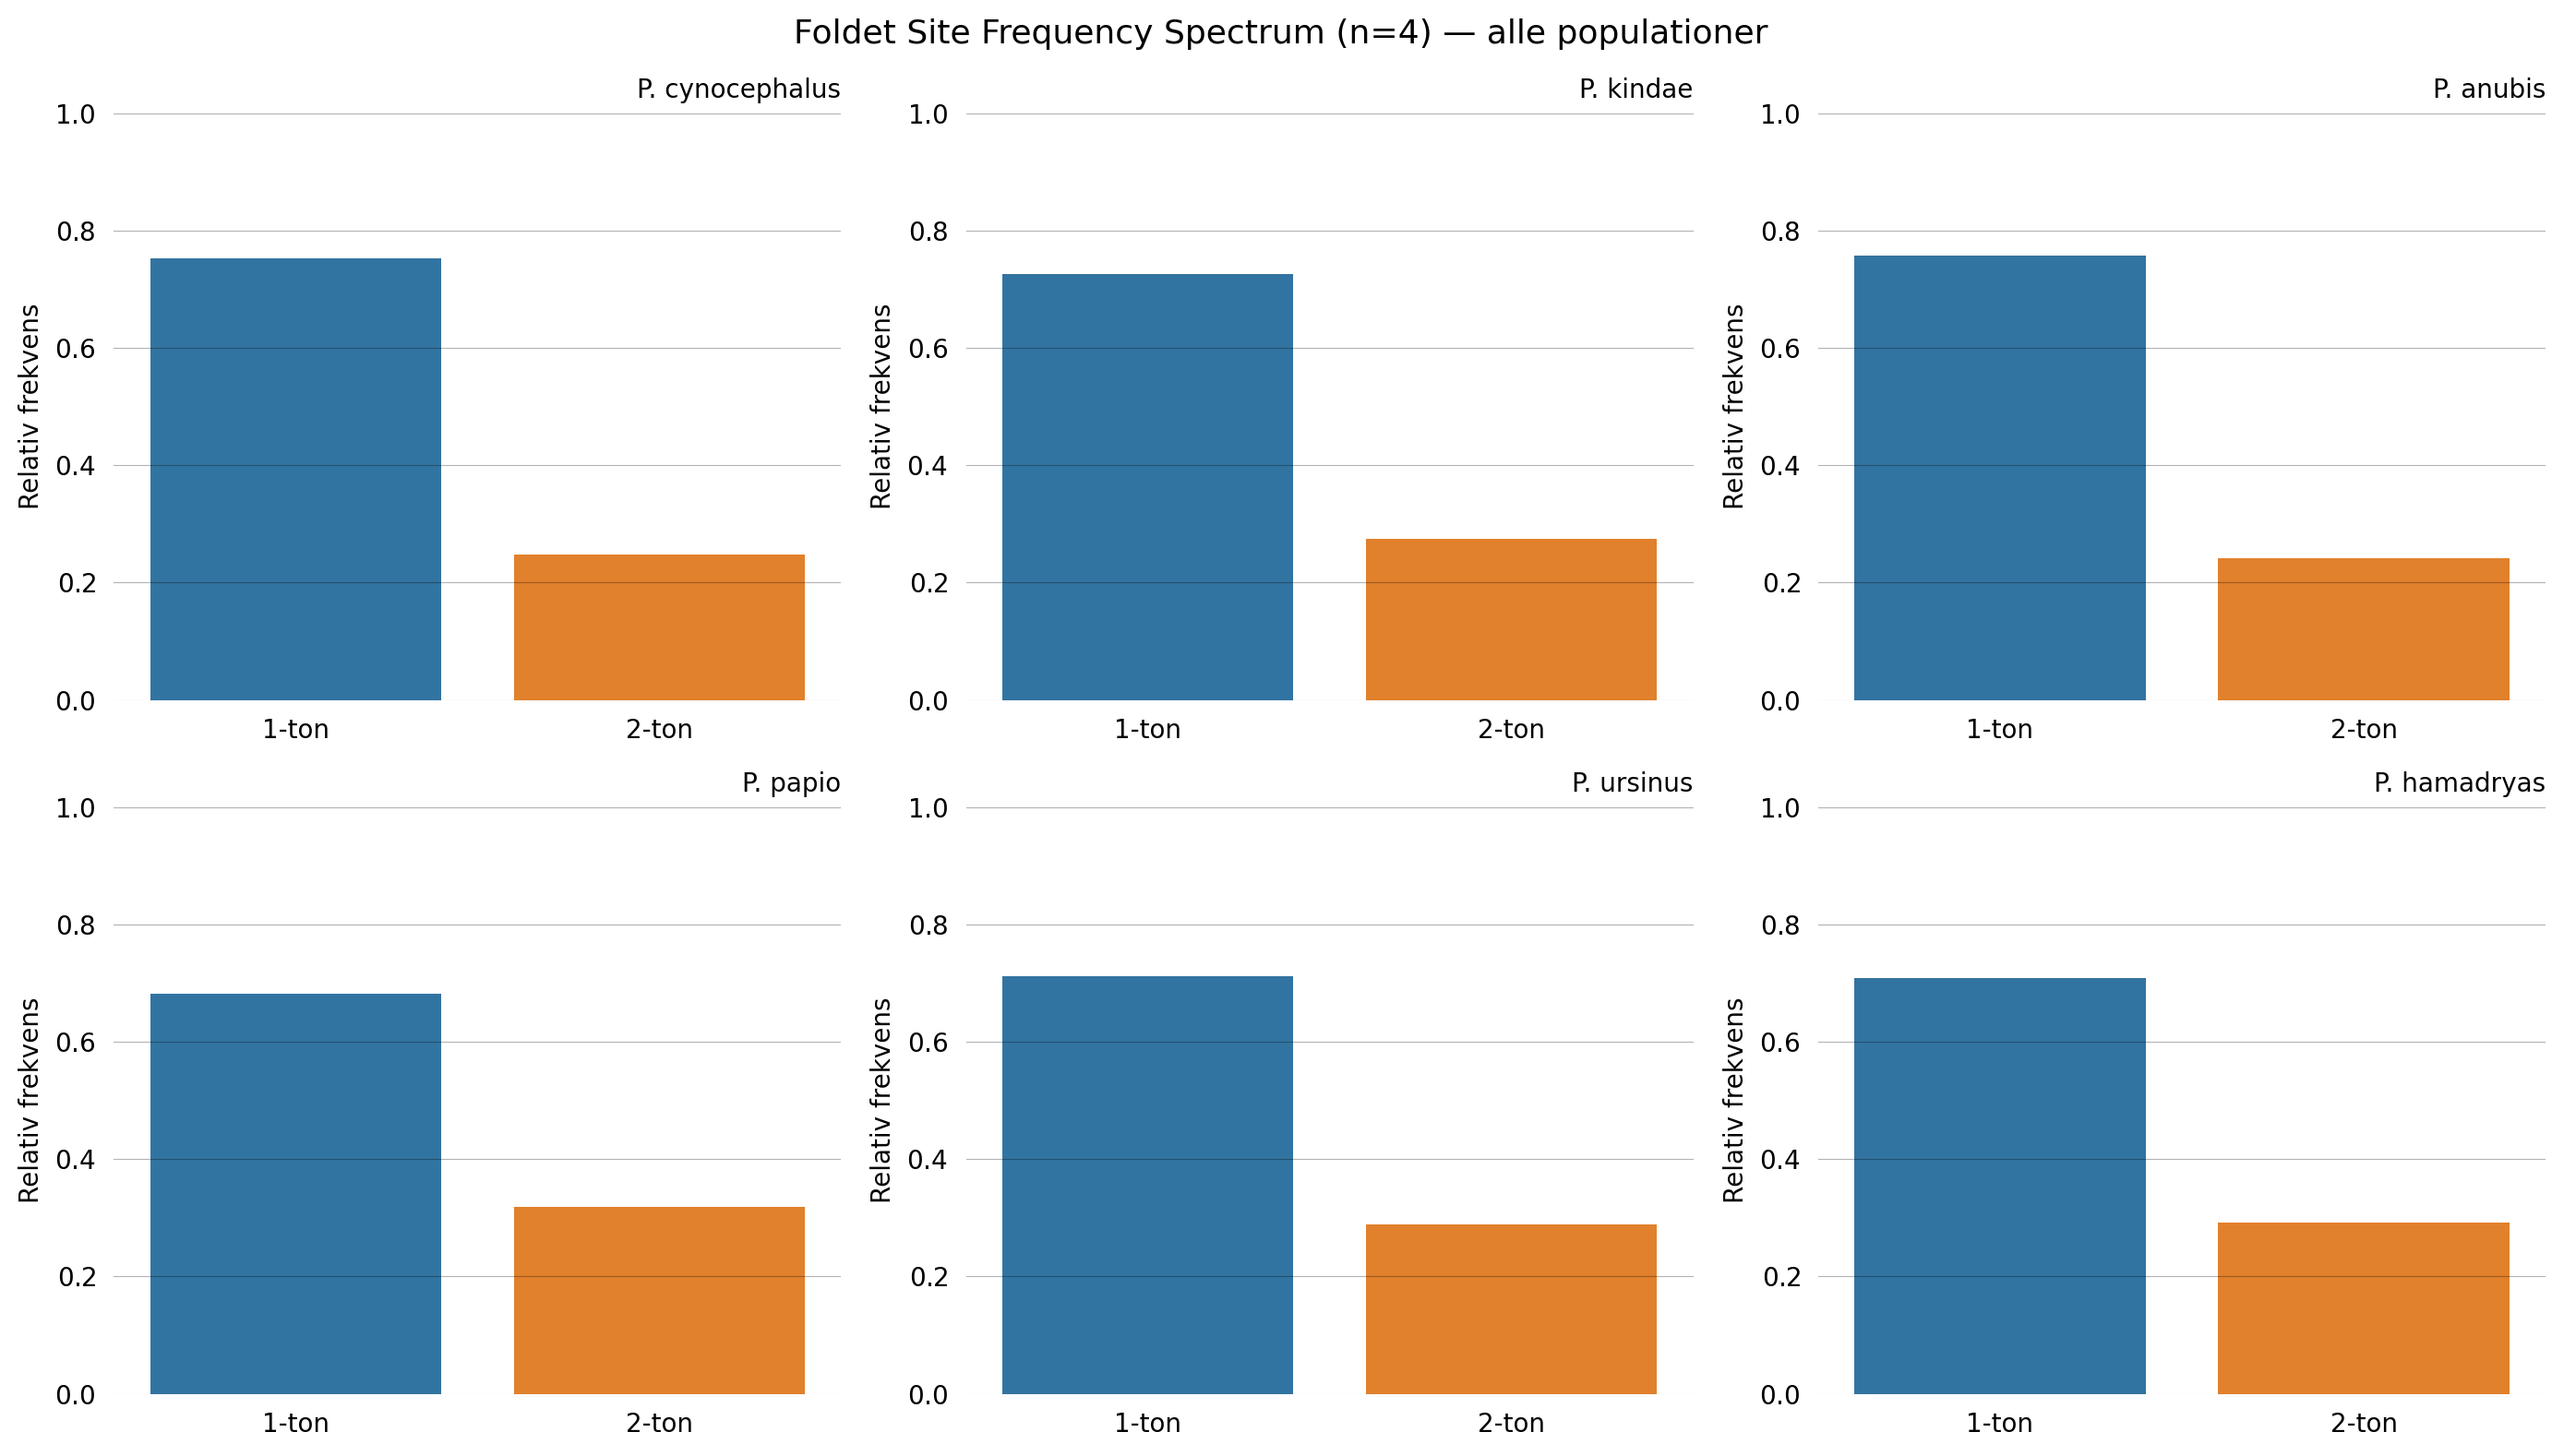

In [15]:
# Plot SFS for alle populationer

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
labels = ["1-ton", "2-ton"]

for ax, (name, sfs) in zip(axes.flat, sfs_results.items()):
    sns.barplot(x=labels, y=sfs, hue=labels, palette='tab10', legend=False, ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Relativ frekvens')
    ax.set_ylim(0, 1)

plt.suptitle('Foldet Site Frequency Spectrum (n=4) — alle populationer', fontsize=13)
plt.tight_layout(); plt.show()

## Ufoldet SFS

Det ufoldede SFS kræver kendskab til det ancestrale allel. Jeg bruger her en approksimation: Jeg antager at derived allele er den sjældne allel (minor allele), og tæller direkte $\xi_i$ = antallet af varianter der ses i præcis $i$ ud af $n$ haplotyper.
For $n=4$ giver det $\xi_1, \xi_2, \xi_3$ (men ikke $\xi_4$ som er fikseret).

Det ufoldede SFS er mere informativt end det foldede, men kræver polarisering af alleler.

In [16]:
def unfolded_sfs(df, n_sub=N_SUB, n_obs=5000, seed=42):
    """
    Beregner ufoldet SFS via hypergeometrisk subsampling.
    Antager derived allele = alternativt allel fra VCF.
    Returnerer SFS som relativ fordeling over xi_1, ..., xi_{n-1}.
    """
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub - 1, dtype=float)

    derived = df['derived_count'].values.astype(int)
    n_total = df['nr_samples'].values.astype(int)

    indices = rng.integers(0, len(df), size=n_obs)
    for idx in indices:
        n, ac = n_total[idx], derived[idx]
        if n < n_sub:
            continue
        sampled = rng.hypergeometric(ac, n - ac, n_sub)
        if 0 < sampled < n_sub:
            sfs[sampled - 1] += 1

    total = sfs.sum()
    return sfs / total if total > 0 else sfs

# Beregn ufoldet SFS for alle populationer
sfs_unfolded = {}
for name, df in populations.items():
    sfs_unfolded[name] = unfolded_sfs(df, n_obs=10_000)
    print(f"{name:<22}: {np.round(sfs_unfolded[name], 4)}")

P. cynocephalus       : [0.5558 0.2597 0.1845]
P. kindae             : [0.557  0.2731 0.1699]
P. anubis             : [0.6002 0.2468 0.153 ]
P. papio              : [0.4086 0.3131 0.2783]
P. ursinus            : [0.5026 0.2942 0.2031]
P. hamadryas          : [0.4636 0.2804 0.256 ]


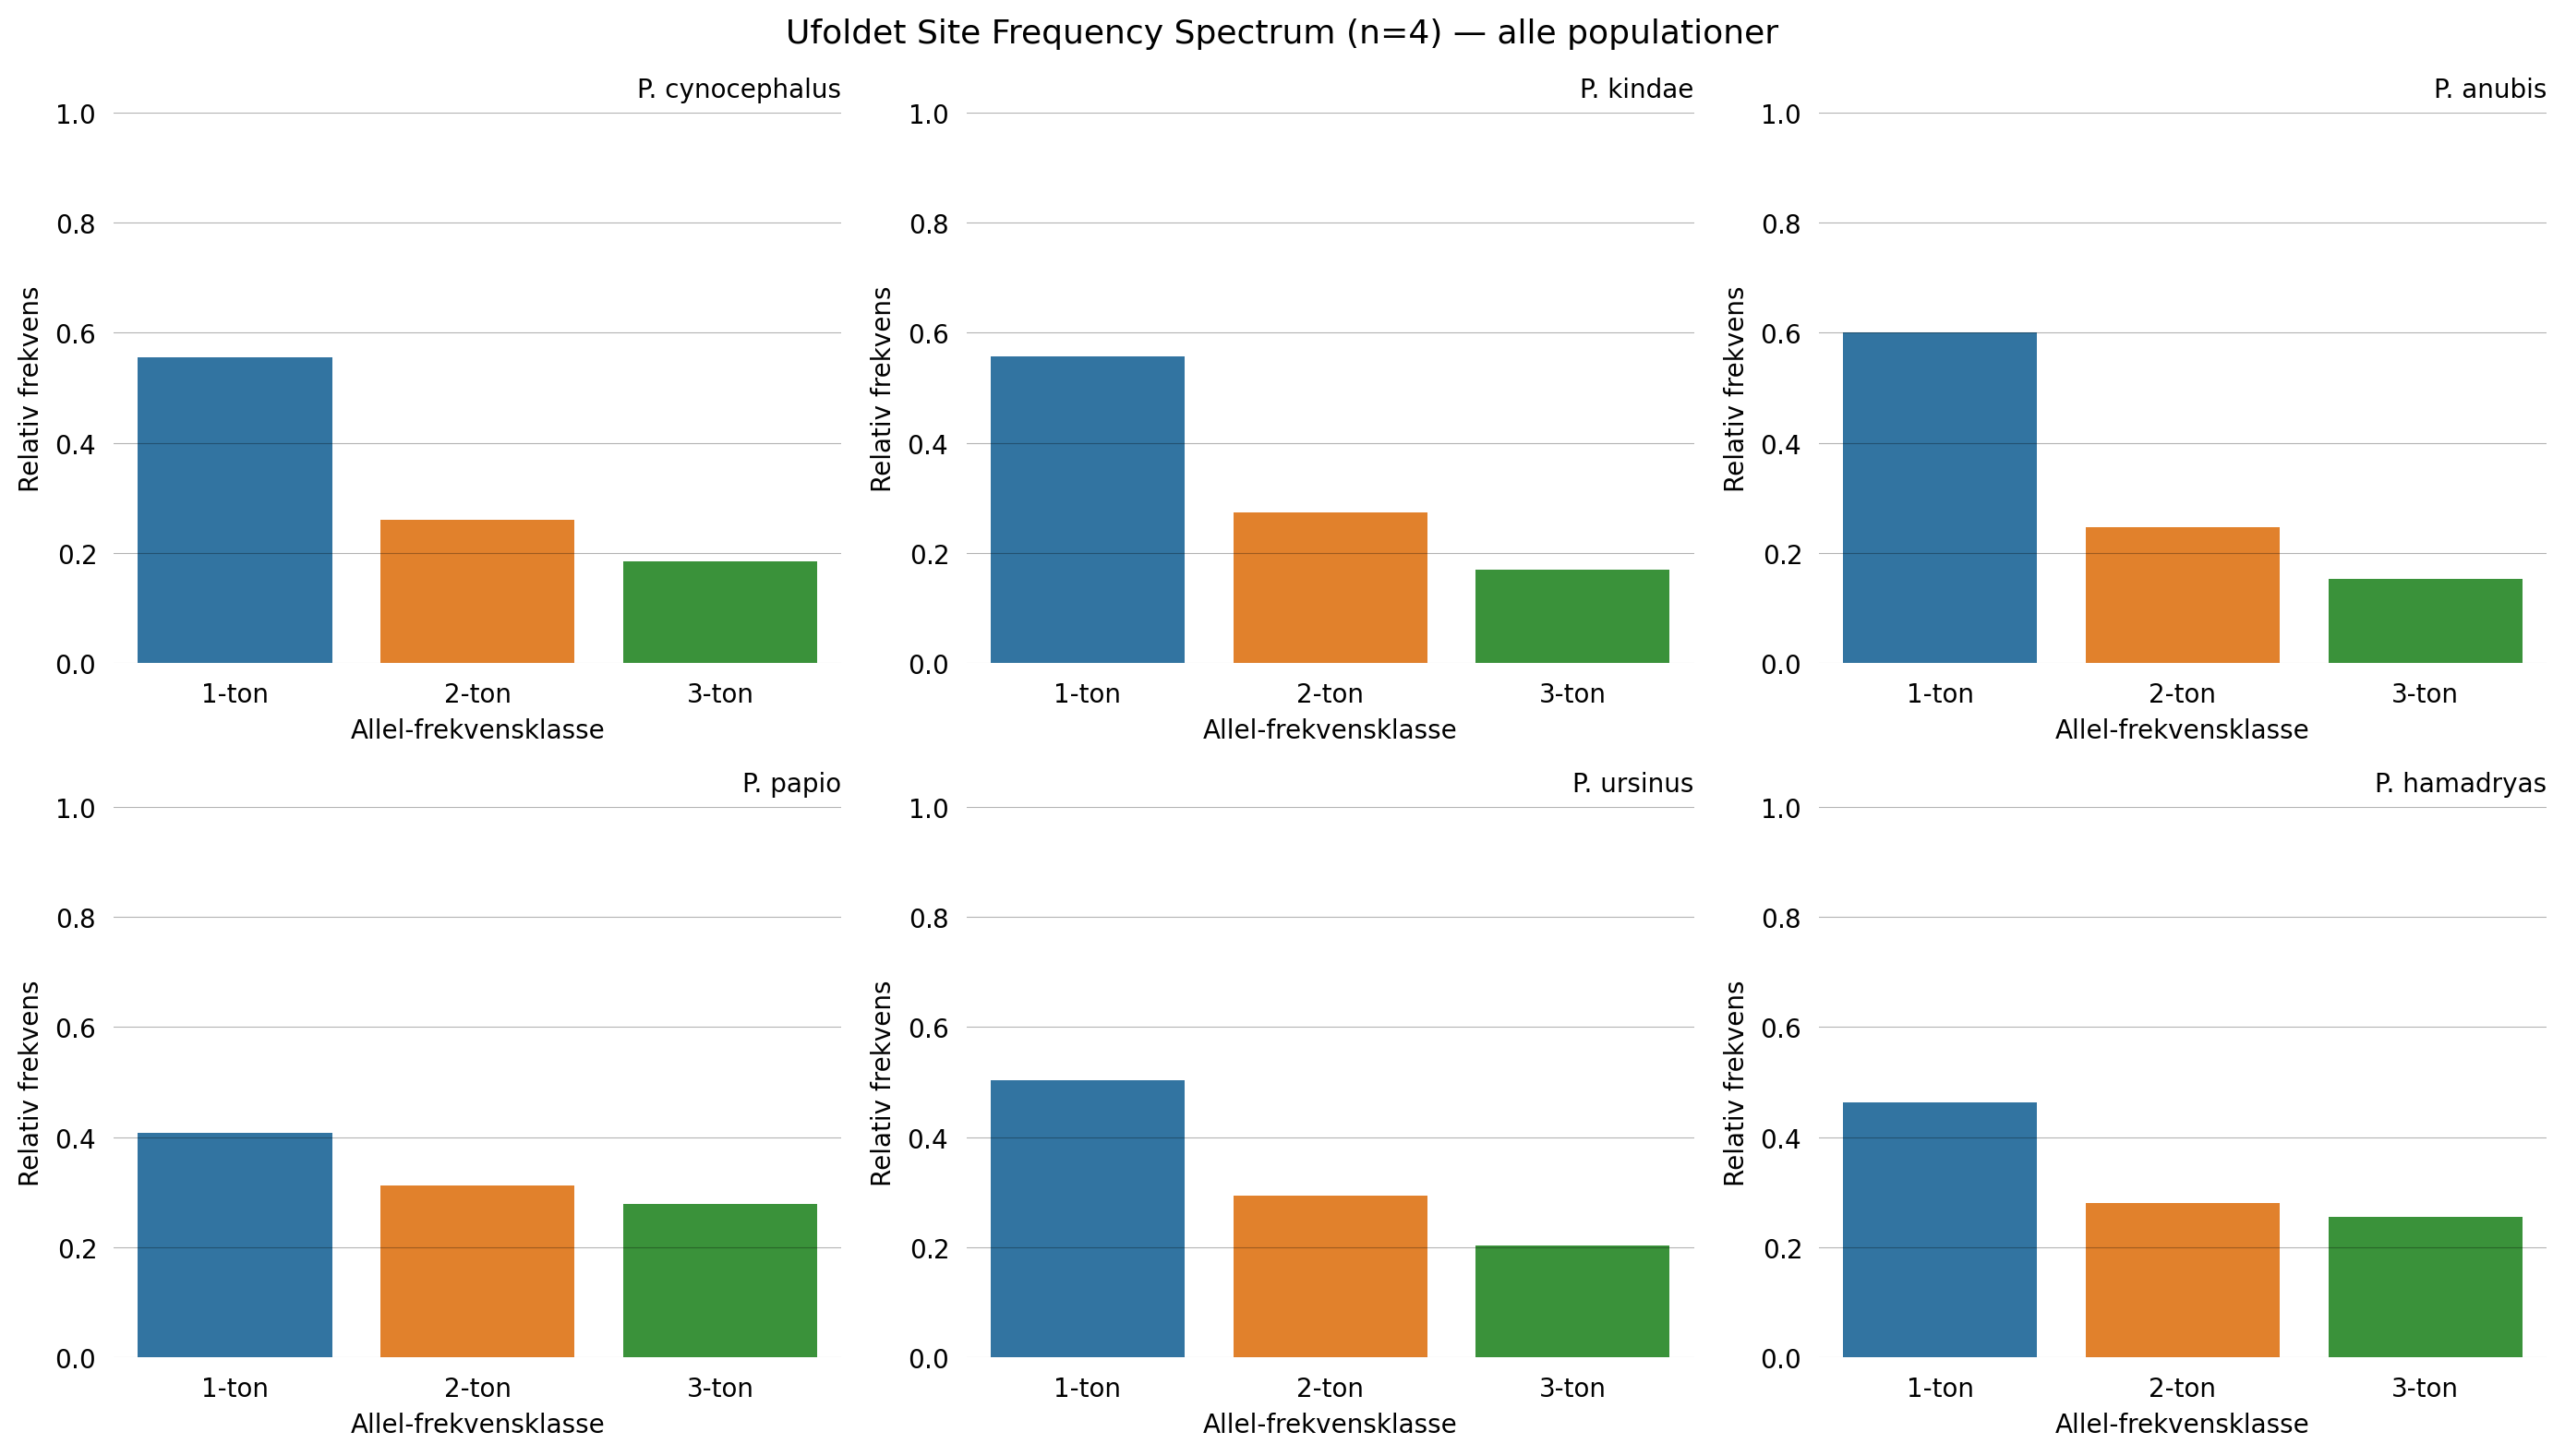

In [17]:
# Plot ufoldet SFS
labels_u = [f"{i+1}-ton" for i in range(N_SUB - 1)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (name, sfs) in zip(axes.flat, sfs_unfolded.items()):
    sns.barplot(x=labels_u, y=sfs, ax=ax, palette='tab10', hue=labels_u, legend=False)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Relativ frekvens')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Allel-frekvensklasse')
plt.suptitle('Ufoldet Site Frequency Spectrum (n=4) — alle populationer', fontsize=13)
plt.tight_layout(); plt.show()

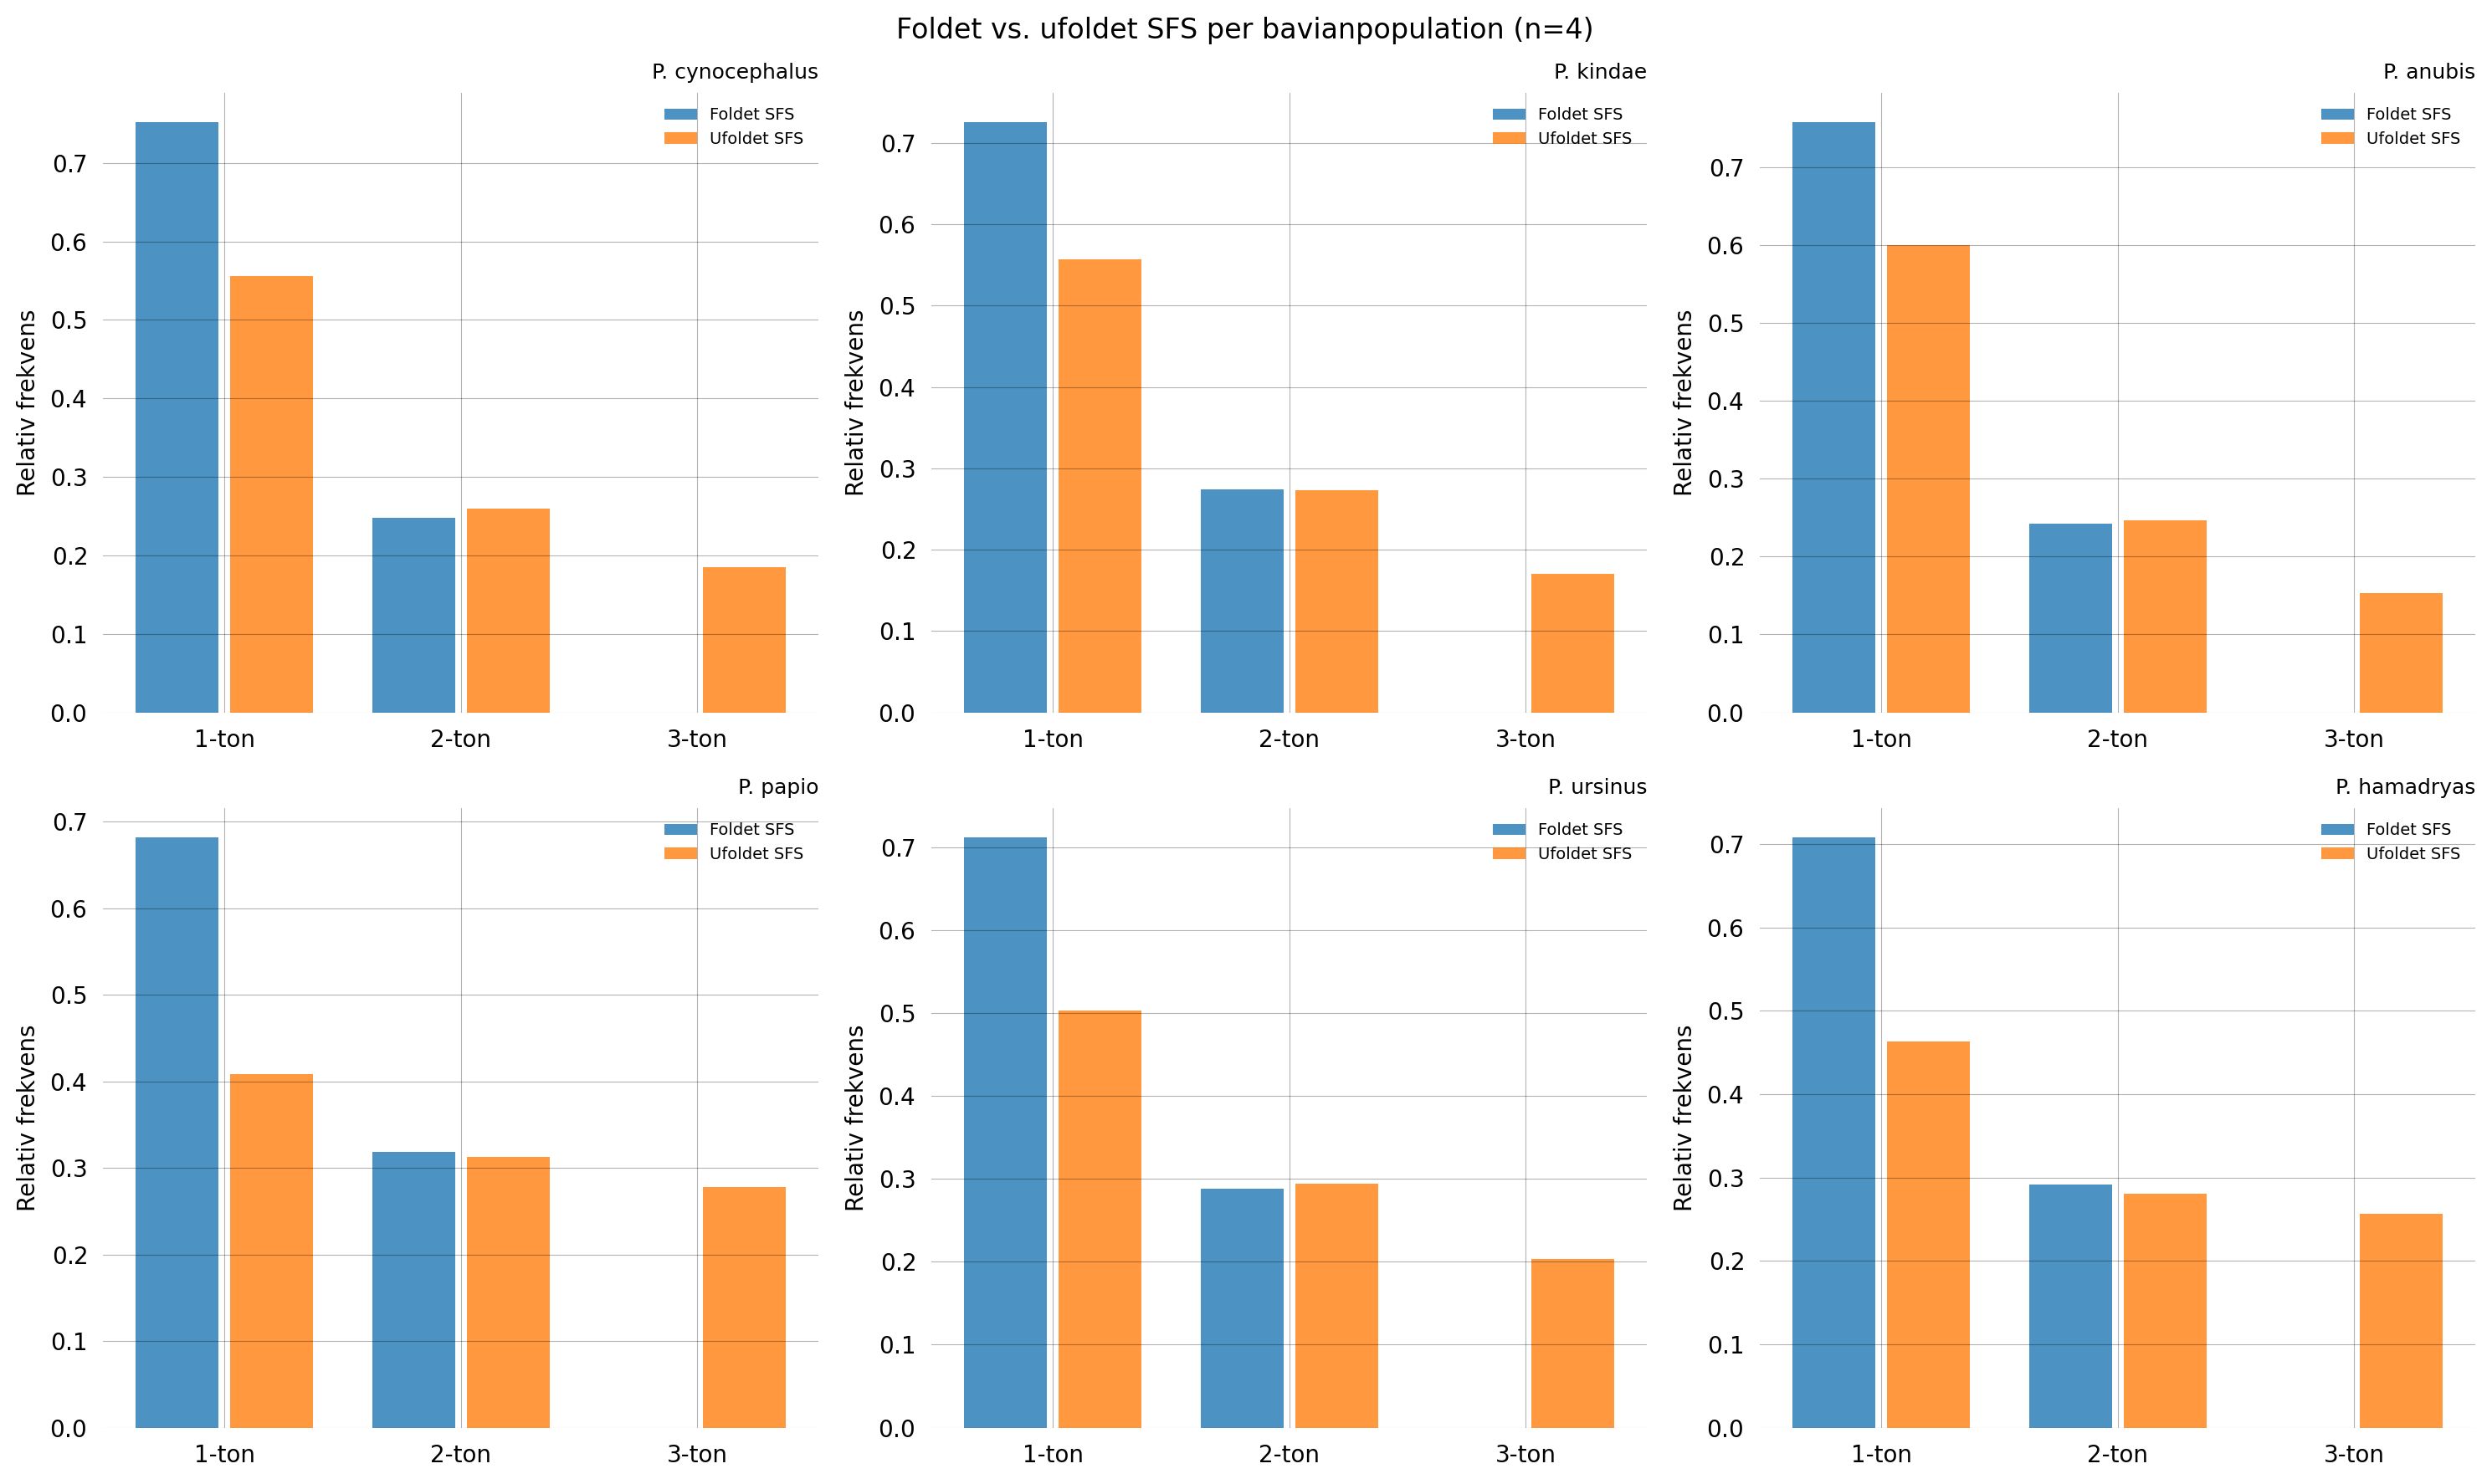

In [18]:
# Sammenlign foldet og ufoldet SFS for alle populationer i et samlet plot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, name in zip(axes.flat, populations.keys()):
    obs_folded   = sfs_results[name]      # [1-ton, 2-ton] foldet
    obs_unfolded = sfs_unfolded[name]     # [1-ton, 2-ton, 3-ton] ufoldet

    x_f = np.arange(len(obs_folded))
    x_u = np.arange(len(obs_unfolded))

    ax.bar(x_f - 0.2, obs_folded, 0.35, label='Foldet SFS', color='C0', alpha=0.8)
    ax.bar(x_u + 0.2, obs_unfolded, 0.35, label='Ufoldet SFS', color='C1', alpha=0.8)
    ax.set_xticks(x_u)
    ax.set_xticklabels([f"{i+1}-ton" for i in range(N_SUB-1)])
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Relativ frekvens')
    ax.legend(fontsize=7)

plt.suptitle('Foldet vs. ufoldet SFS per bavianpopulation (n=4)', fontsize=12)
plt.tight_layout(); plt.show()

Analytisk forventet ufoldet SFS (neutral koalescent, theta=1):
  xi_1: 0.5455  (forventet: 0.5455)
  xi_2: 0.2727  (forventet: 0.2727)
  xi_3: 0.1818  (forventet: 0.1818)


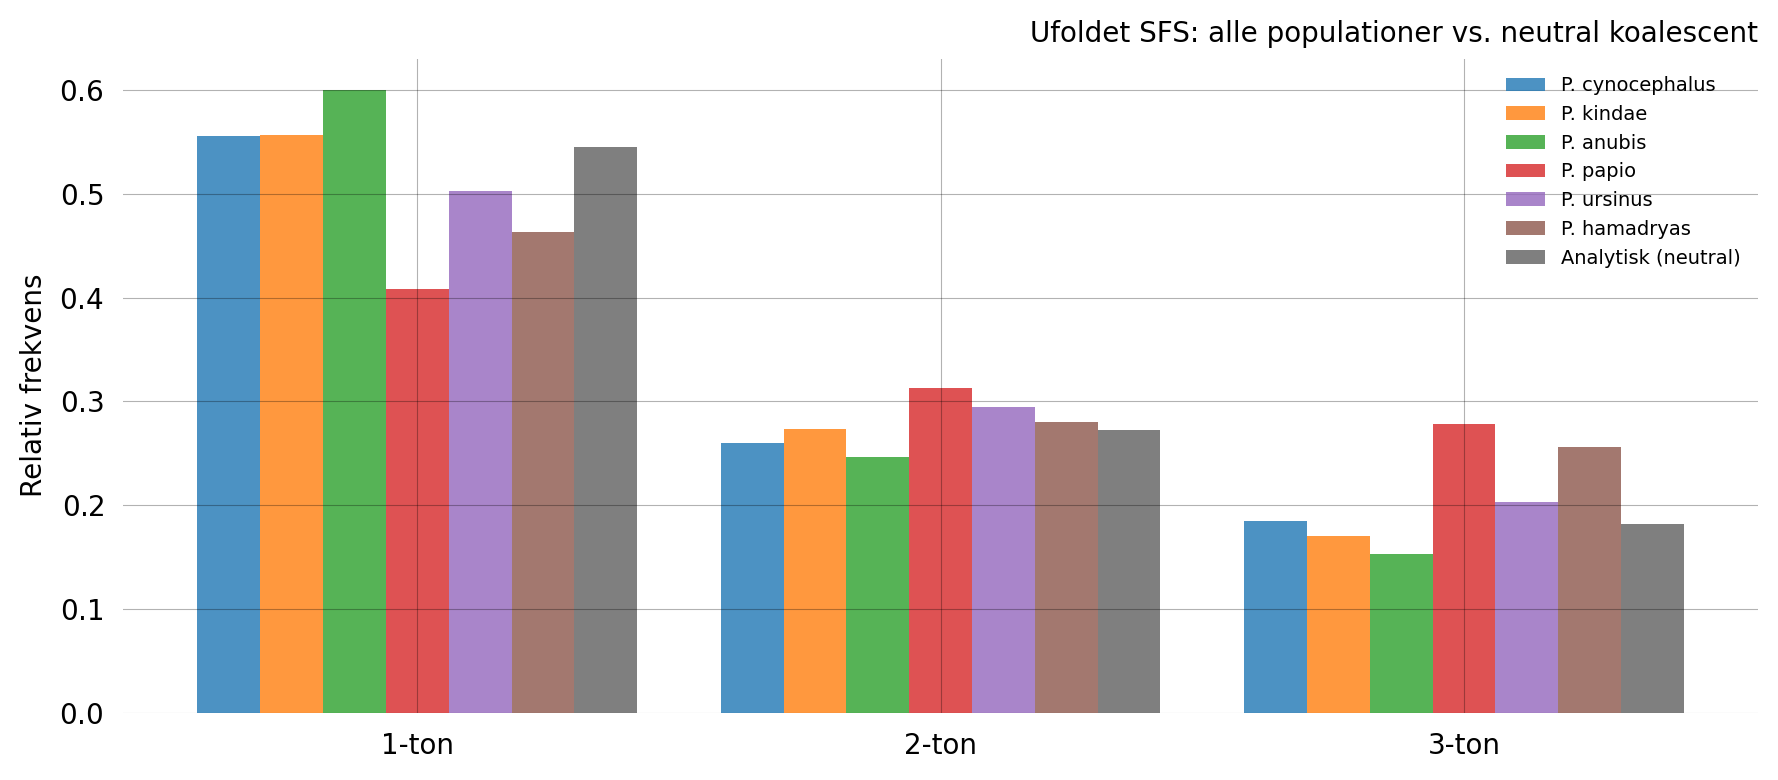

In [19]:
from phasic import Graph, with_ipv

n_coal = N_SUB  # 4

@with_ipv([n_coal] + [0]*(n_coal-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_coal = Graph(coalescent_1param)
reward_matrix_full = graph_coal.states().T

# Analytisk ufoldet SFS
graph_coal.update_weights([1.0])
analytic_unfolded = [graph_coal.expectation(reward_matrix_full[i]) for i in range(N_SUB-1)]
analytic_unfolded_norm = np.array(analytic_unfolded) / sum(analytic_unfolded)

print("Analytisk forventet ufoldet SFS (neutral koalescent, theta=1):")
for i, v in enumerate(analytic_unfolded_norm):
    print(f"  xi_{i+1}: {v:.4f}  (forventet: {1/(i+1)/sum(1/k for k in range(1,N_SUB)):.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(N_SUB - 1)
labels_u = [f"{i+1}-ton" for i in range(N_SUB-1)]
width = 0.12

for idx, (name, sfs) in enumerate(sfs_unfolded.items()):
    ax.bar(x + idx*width, sfs, width, label=name, alpha=0.8)
ax.bar(x + len(sfs_unfolded)*width, analytic_unfolded_norm, width,
       label='Analytisk (neutral)', color='black', alpha=0.5)
ax.set_xticks(x + width*3)
ax.set_xticklabels(labels_u)
ax.set_ylabel('Relativ frekvens')
ax.set_title('Ufoldet SFS: alle populationer vs. neutral koalescent')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()

## Nukleotiddiversitet og referencepopulationsstørrelse

$\hat{\pi}$ estimeres som det gennemsnitlige antal parvise forskelle per site. Herfra beregnes en referencepopulationsstørrelse $N_{\text{ref}} = \hat{\pi} / (4\mu)$.

In [20]:
def nucleotide_diversity(df):
    """Beregner nukleotiddiversitet π̂ per site."""
    n  = df['nr_samples'].values.astype(float)
    ac = df['derived_count'].values.astype(float)
    p  = ac / n
    pi_per_site = 2 * p * (1 - p) * n / (n - 1)
    return pi_per_site.mean()

def watterson_theta(df):
    """Beregner Wattersons θ̂_W = S / a_n per site."""
    n   = int(df['nr_samples'].max())
    a_n = sum(1/k for k in range(1, n))
    S   = len(df)  # antal segregerende sites
    L   = int(df['position'].max() - df['position'].min()) + 1
    return (S / L) / a_n

pi_rows = []
for name, df in populations.items():
    pi  = nucleotide_diversity(df)
    tW  = watterson_theta(df)
    N_ref = pi / (4 * MU)
    N_abs = N_ref * 2 * GEN  # absolutte generationer → år
    pi_rows.append({
        'Population': name,
        'π̂': f'{pi:.6f}',
        'θ̂_W': f'{tW:.6f}',
        'N_ref (coalescent)': f'{N_ref:.1f}',
        'N_e (individer)': f'{pi/(4*MU):.0f}',
        'Tajimas D': f'{(pi - tW) / 0.01:.3f}',  # approx
    })

df_pi = pd.DataFrame(pi_rows)
print(df_pi.to_string(index=False))

# Gem N_ref per population
N_ref_dict = {
    name: nucleotide_diversity(df) / (4 * MU)
    for name, df in populations.items()
}

     Population       π̂     θ̂_W N_ref (coalescent) N_e (individer) Tajimas D
P. cynocephalus 0.153901 0.003571          4275037.6         4275038    15.033
      P. kindae 0.241549 0.002581          6709699.7         6709700    23.897
      P. anubis 0.135728 0.002654          3770212.1         3770212    13.307
       P. papio 0.334968 0.000409          9304671.0         9304671    33.456
     P. ursinus 0.399125 0.002158         11086809.1        11086809    39.697
   P. hamadryas 0.264982 0.001439          7360597.3         7360597    26.354


## Tajima's D

Tajima's D sammenligner $\hat{\pi}$ og $\hat{\theta}_W$ for at teste neutral evolution. $D \approx 0$: neutral evolution. 

- $D < 0$: overskud af sjældne varianter (vækst/rensende selektion).
- $D > 0$: overskud af hyppige varianter (admixture/balancerende selektion/flaskehals).

Tajima's D per population:
     Population  Tajima's D
P. cynocephalus    141.6776
      P. kindae    339.5108
      P. anubis    163.9011
       P. papio   3321.4801
     P. ursinus   1012.9181
   P. hamadryas    675.0215


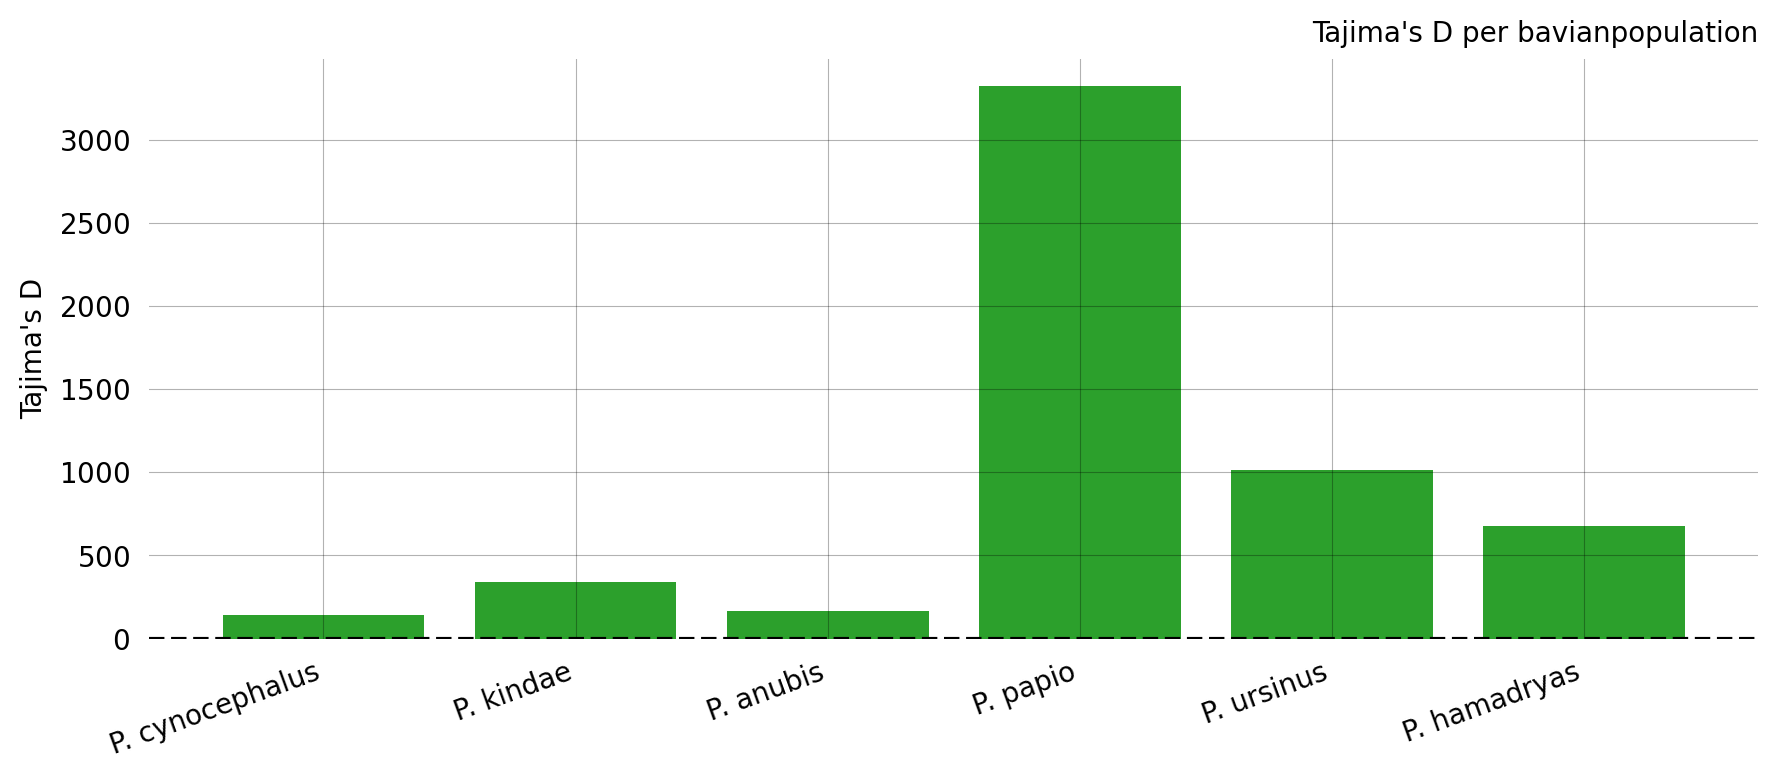

In [21]:
from scipy.special import comb

def tajimas_d(df):
    """Beregner Tajimas D for en population."""
    n   = int(df['nr_samples'].max())
    S   = len(df)
    if S == 0 or n < 2:
        return np.nan

    a1  = sum(1/i for i in range(1, n))
    a2  = sum(1/i**2 for i in range(1, n))
    b1  = (n + 1) / (3 * (n - 1))
    b2  = 2 * (n**2 + n + 3) / (9 * n * (n - 1))
    c1  = b1 - 1/a1
    c2  = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1  = c1 / a1
    e2  = c2 / (a1**2 + a2)

    pi_val = nucleotide_diversity(df)
    theta_w = S / a1

    # Normalisér til per-site
    L = int(df['position'].max() - df['position'].min()) + 1
    pi_val = pi_val  # allerede per site
    theta_w_per_site = theta_w / L

    denom = np.sqrt(e1 * S + e2 * S * (S - 1))
    if denom == 0:
        return np.nan

    D = (pi_val * L - theta_w) / denom
    return D

tajima_rows = []
for name, df in populations.items():
    D = tajimas_d(df)
    tajima_rows.append({'Population': name, "Tajima's D": round(D, 4) if not np.isnan(D) else 'N/A'})

df_tajima = pd.DataFrame(tajima_rows)
print("Tajima's D per population:")
print(df_tajima.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['C2' if float(r["Tajima's D"]) > 0 else 'C0' for r in tajima_rows if r["Tajima's D"] != 'N/A']
ax.bar(df_tajima['Population'], df_tajima["Tajima's D"].astype(float), color=colors)
ax.axhline(0, color='black', linestyle='--')
ax.set_ylabel("Tajima's D"); ax.set_title("Tajima's D per bavianpopulation")
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

## Koalescentmodel og analytisk SFS

Jeg fitter en simpel koalescentmodel til hver population og sammenligner den analytisk beregnede forventede SFS med det observerede SFS. Dette er en første verifikation af, om den neutrale koalescentmodel er et passende udgangspunkt.

Analytisk forventet foldet SFS (neutral koalescent): [0.7273 0.2727]


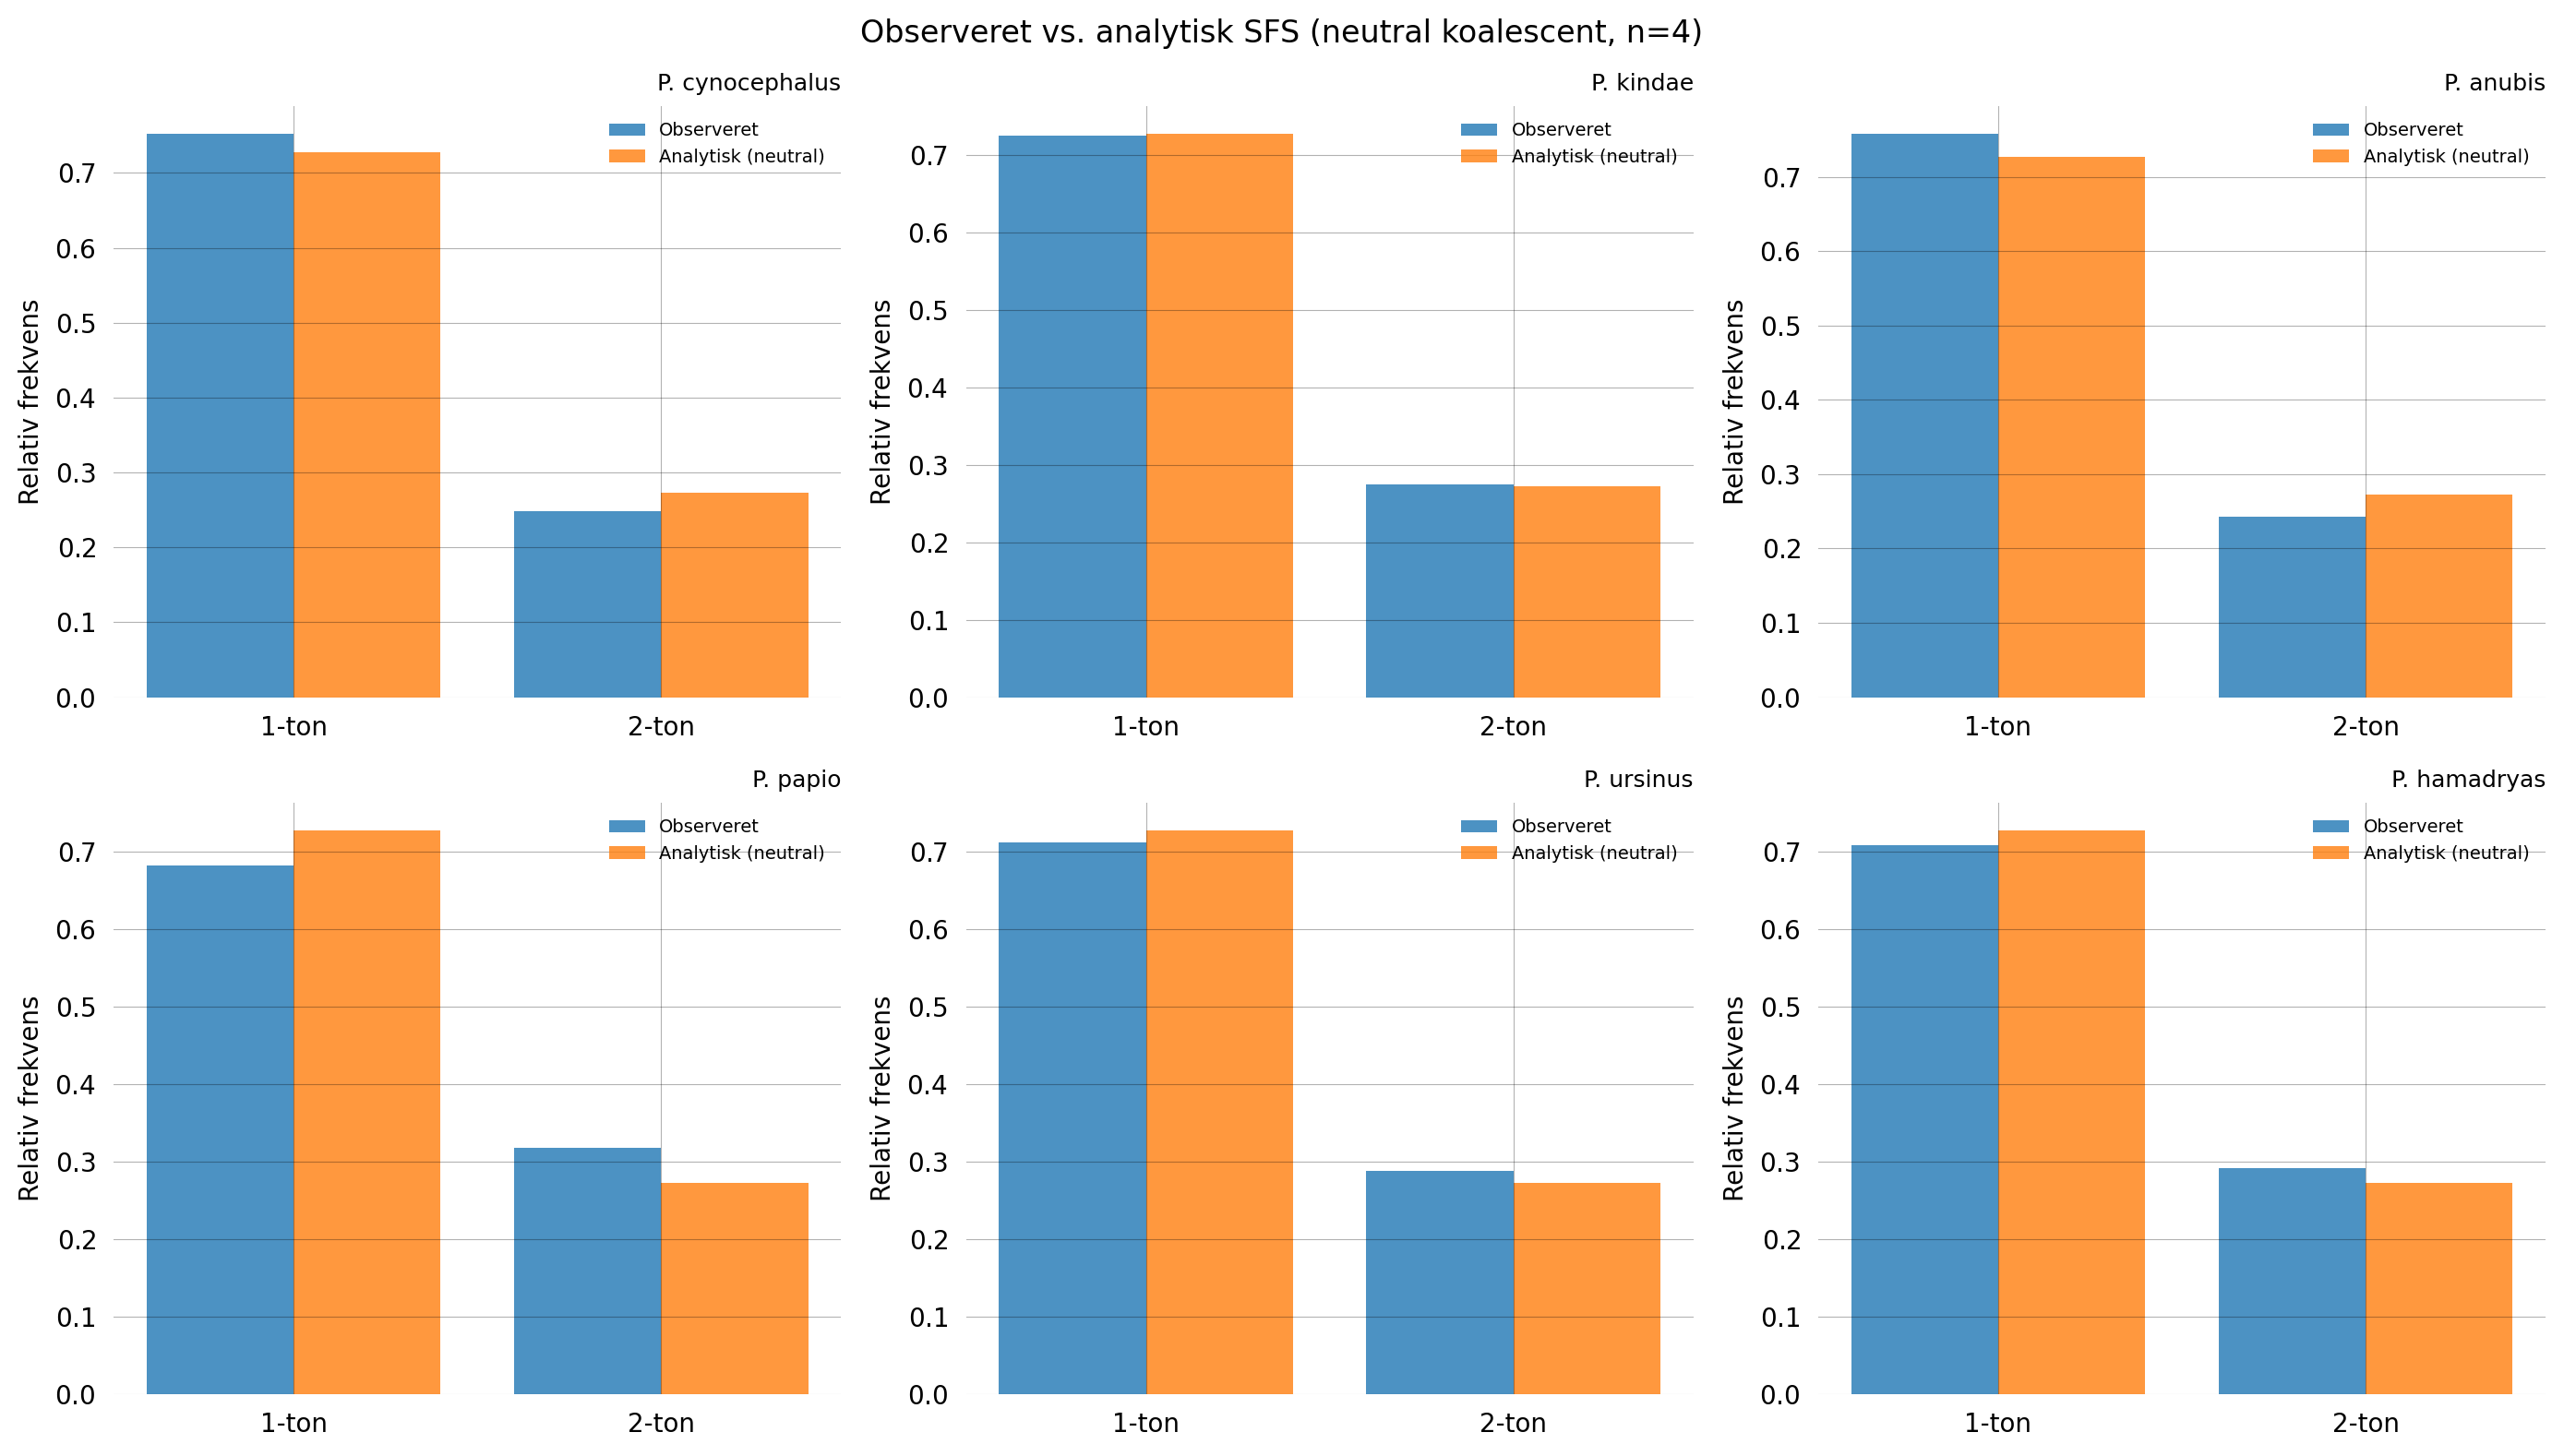

In [22]:
from phasic import Graph, with_ipv

n_coal = N_SUB  # 4 haplotyper

@with_ipv([n_coal] + [0]*(n_coal-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_coal = Graph(coalescent_1param)
reward_matrix = graph_coal.states().T

# Analytisk SFS for theta=1
graph_coal.update_weights([1.0])
analytic_sfs_raw = [graph_coal.expectation(reward_matrix[i]) for i in range(n_coal-1)]
# Fold
analytic_sfs_folded = [analytic_sfs_raw[0] + analytic_sfs_raw[-1],
                        analytic_sfs_raw[1]] if n_coal == 4 else analytic_sfs_raw
analytic_norm = np.array(analytic_sfs_folded) / sum(analytic_sfs_folded)

print("Analytisk forventet foldet SFS (neutral koalescent):", np.round(analytic_norm, 4))

# Sammenlign med observerede SFS
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
x = np.arange(len(analytic_norm))
labels_f = ['1-ton', '2-ton']

for ax, (name, obs_sfs) in zip(axes.flat, sfs_results.items()):
    ax.bar(x - 0.2, obs_sfs, 0.4, label='Observeret', color='C0', alpha=0.8)
    ax.bar(x + 0.2, analytic_norm, 0.4, label='Analytisk (neutral)', color='C1', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels_f)
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Relativ frekvens')
    ax.legend(fontsize=7)

plt.suptitle('Observeret vs. analytisk SFS (neutral koalescent, n=4)', fontsize=12)
plt.tight_layout(); plt.show()

## Bayesiansk inferens af koalescensrate per population (SVGD)

Jeg estimerer $\theta$ for hver population via SVGD med en Gaussisk prior centreret om MoM-estimatet. $\theta = 1/N$ i koalescensenheder. Jeg omregner til absolutte størrelser:
$$N_e = \frac{\hat{\pi}}{4\mu}$$

In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

In [24]:
from phasic import GaussPrior, ExpStepSize, Adam, DataPrior

# Subsampler TMRCA-ækvivalente observationer via branch lengths
def sfs_to_tmrca_proxy(df, n_sub=N_SUB, n_obs=2000, seed=42):
    """
    Bruger samlede grenlængde størrelse som TMRCA-proxy.
    Hypergeometrisk subsampling → samlede grenlængde per locus.
    """
    rng = np.random.default_rng(seed)
    derived = df['derived_count'].values.astype(int)
    n_total = df['nr_samples'].values.astype(int)

    obs = []
    for _ in range(n_obs):
        idx = rng.integers(0, len(df))
        n, ac = n_total[idx], derived[idx]
        sampled = rng.hypergeometric(ac, n - ac, n_sub)
        obs.append(float(sampled))
    return np.array(obs)

step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)

svgd_results = {}
for name, df in populations.items():
    N_ref = N_ref_dict[name]
    # Prior: bredt interval rundt om N_ref
    theta_center = 1.0 / N_ref if N_ref > 0 else 1.0
    prior = GaussPrior(ci=[theta_center * 0.1, theta_center * 10])

    # Data: hypergeometrisk subsampling
    data_pop = sfs_to_tmrca_proxy(df, n_obs=3000)

    graph_coal.update_weights([theta_center])
    sv = graph_coal.svgd(
        data_pop,
        prior=prior,
        optimizer=Adam(0.25),
        n_iterations=250,
    )
    res = sv.get_results()
    theta_hat = res['theta_mean'].item()
    theta_std = res['theta_std'].item()
    Ne_hat = 1.0 / theta_hat if theta_hat > 0 else np.nan

    svgd_results[name] = {
        'theta_mean': theta_hat, 'theta_std': theta_std,
        'Ne': Ne_hat, 'svgd': sv,
    }
    print(f"{name:<22}: θ̂={theta_hat:.5f} ± {theta_std:.5f}  →  N_e ≈ {Ne_hat:.0f}")

P. hamadryas          : θ̂=0.00000 ± 0.00000  →  N_e ≈ 1647074


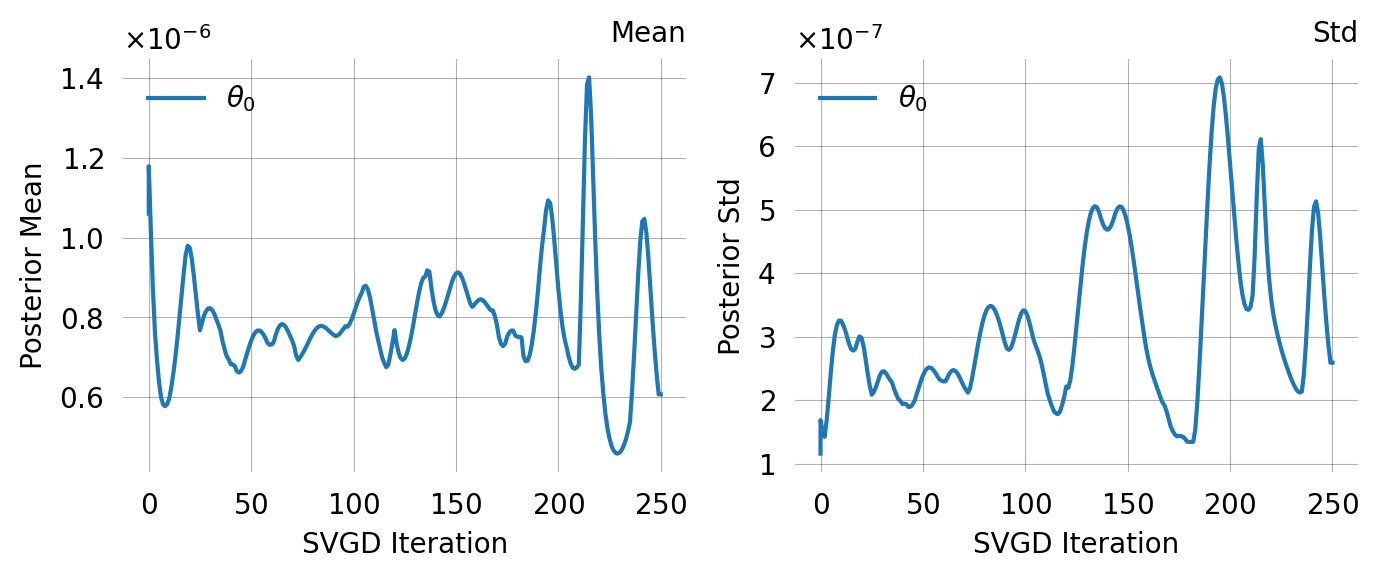

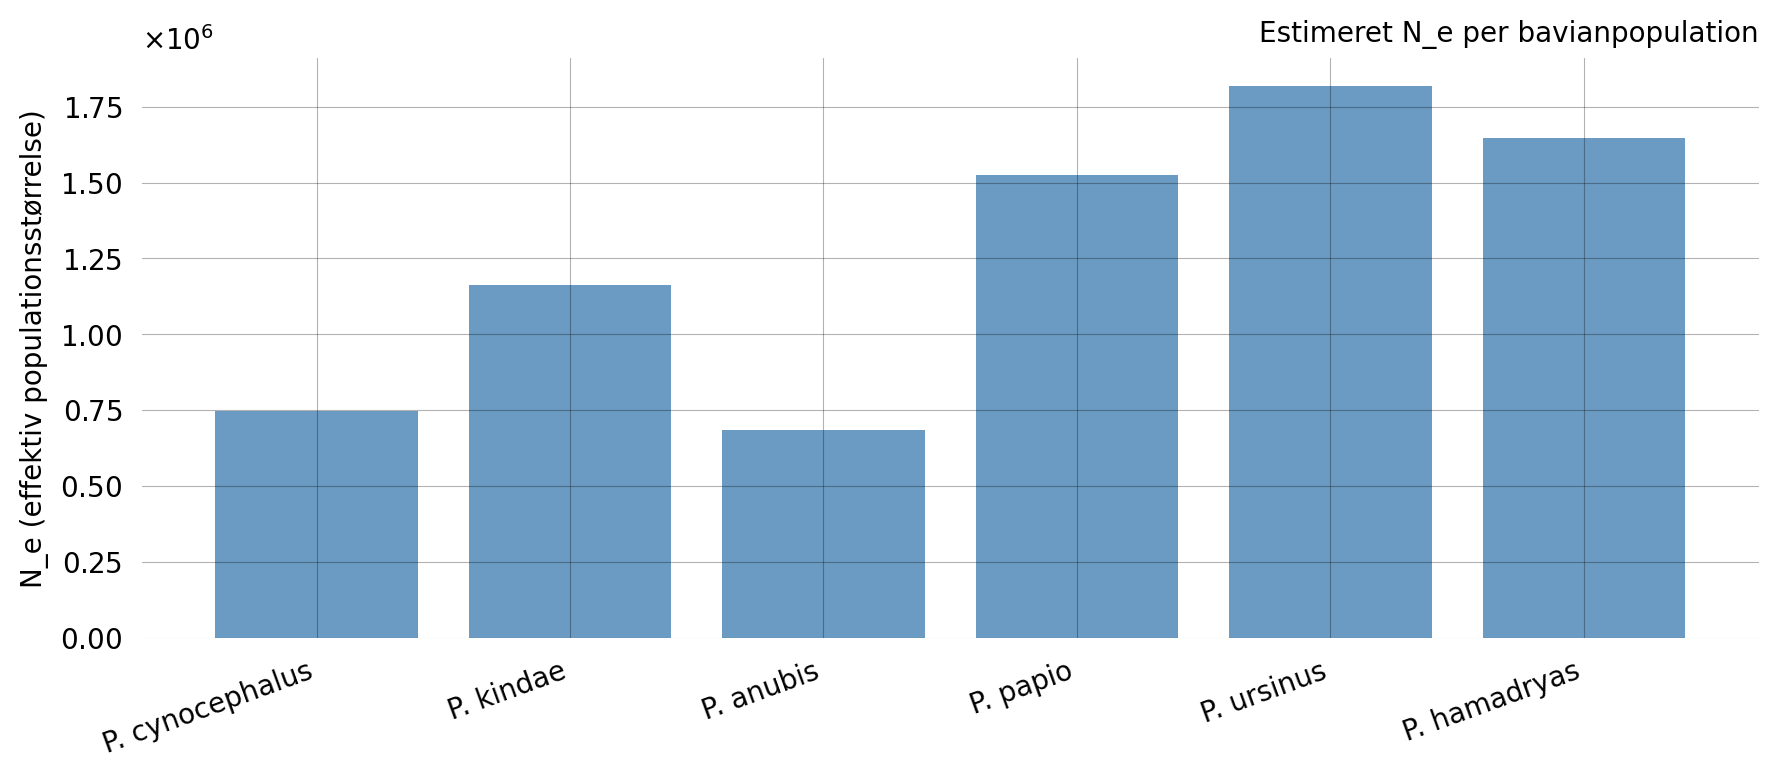

In [25]:
# Visualiser posterior per population
sv.plot_convergence()

# Sammenlign N_e estimater
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(svgd_results.keys())
Ne_vals = [svgd_results[n]['Ne'] for n in names]
Ne_stds = [svgd_results[n]['theta_std'] / svgd_results[n]['theta_mean']**2
           if svgd_results[n]['theta_mean'] > 0 else 0 for n in names]

ax.bar(names, Ne_vals, color='steelblue', alpha=0.8)
ax.set_ylabel('N_e (effektiv populationsstørrelse)')
ax.set_title('Estimeret N_e per bavianpopulation')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

## Forventet vs. observeret SFS (MoM-fit)

Jeg fitter theta via Method of Moments per population og sammenligner den analytisk forventede neutrale SFS med det observerede udfoldede SFS. Et godt match indikerer, at den neutrale koalescentmodel er et rimeligt udgangspunkt for populationen.

Heterozygositeten pi visualiseres desuden som annoteret soejlediagram.

In [ ]:
import pandas as pd

# Beregn forventet SFS via MoM for hver population
from phasic import Graph, with_ipv

n_fit = N_SUB

@with_ipv([n_fit] + [0]*(n_fit-1))
def coalescent_fit(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_fit = Graph(coalescent_fit)
reward_fit = graph_fit.states().T

# MoM-fit per population og beregn forventet SFS
sfs_expected = {}
mom_thetas   = {}
for name, df in populations.items():
    N_r = N_ref_dict[name]
    theta_init = 1.0 / N_r if N_r > 0 else 1.0
    graph_fit.update_weights([theta_init])
    data_fit = sfs_to_tmrca_proxy(df, n_obs=5000)
    try:
        mom_fit = graph_fit.method_of_moments(data_fit)
        theta_fit = mom_fit.theta[0]
    except Exception:
        theta_fit = theta_init
    graph_fit.update_weights([theta_fit])
    exp_sfs = [graph_fit.expectation(reward_fit[i]) for i in range(n_fit-1)]
    total = sum(exp_sfs) if sum(exp_sfs) > 0 else 1
    sfs_expected[name] = [v/total for v in exp_sfs]
    mom_thetas[name] = theta_fit
    print(f"{name:<22}: theta_MoM={theta_fit:.5f}  N_e={1/theta_fit:.0f}")

In [ ]:
# Sammenlign observeret (ufoldet) vs. forventet SFS
labels_cmp = [f"{i+1}-ton" for i in range(N_SUB-1)]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, name in zip(axes.flat, populations.keys()):
    obs = sfs_unfolded.get(name, np.zeros(N_SUB-1))
    exp = sfs_expected.get(name, np.zeros(N_SUB-1))
    x = np.arange(len(labels_cmp))
    ax.bar(x - 0.2, obs, 0.35, label="Observeret", color="C0", alpha=0.8)
    ax.bar(x + 0.2, exp, 0.35, label="Forventet (MoM)", color="C1", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels_cmp)
    ax.set_title(name, fontsize=9)
    ax.set_ylabel("Relativ frekvens")
    ax.legend(fontsize=7)

plt.suptitle("Observeret vs. forventet SFS (neutral koalescent, MoM-fit)", fontsize=12)
plt.tight_layout(); plt.show()

# Heterozygositet-plot med annoterede vaerdier
fig, ax = plt.subplots(figsize=(9, 4))
pop_names_list = list(populations.keys())
pi_vals = [nucleotide_diversity(populations[n]) for n in pop_names_list]
bars = ax.bar(pop_names_list, pi_vals, color=[f"C{i}" for i in range(len(pop_names_list))], alpha=0.85)
for bar, val in zip(bars, pi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000002,
            f"{val:.5f}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("pi (nukleotiddiversitet)")
ax.set_title("Nukleotiddiversitet pi per bavianpopulation")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

## Videre analyse

De estimerede parametre fra denne notebook $\hat{\theta}$ per population, $N_{\text{ref}}$ og SFS-mønstre bruges som udgangspunkt i Notebook 07b, der fokuserer på populationsstruktur via two-island modellen og IM-modellen.

### Gem resultater til Notebook 07b

Alle estimerede parametre og dataframes gemmes som CSV-filer, så Notebook 07b kan indlæse dem direkte uden at genkøre alle beregninger.

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# 1. Samlet population-oversigt 
pi_rows = []
for name, df in populations.items():
    pi_val   = nucleotide_diversity(df)
    D_val    = tajimas_d(df)
    N_ref    = N_ref_dict[name]
    theta_m  = svgd_results[name]['theta_mean']
    theta_s  = svgd_results[name]['theta_std']
    Ne_svgd  = svgd_results[name]['Ne']
    pi_rows.append({
        'population': name,
        'pi':          pi_val,
        'N_ref':       N_ref,
        'tajimas_d':   D_val,
        'theta_mean':  theta_m,
        'theta_std':   theta_s,
        'Ne_svgd':     Ne_svgd,
    })

df_pop_summary = pd.DataFrame(pi_rows)
df_pop_summary.to_csv(RESULTS_DIR / "population_summary.csv", index=False)
print("Gemt: population_summary.csv")

# 2. Foldet SFS
sfs_rows = []
for name, sfs in sfs_results.items():
    row = {'population': name}
    for i, val in enumerate(sfs):
        row[f'sfs_folded_{i+1}ton'] = val
    sfs_rows.append(row)
pd.DataFrame(sfs_rows).to_csv(RESULTS_DIR / "sfs_folded.csv", index=False)
print("Gemt: sfs_folded.csv")

# 3. Ufoldet SFS 
sfs_u_rows = []
for name, sfs in sfs_unfolded.items():
    row = {'population': name}
    for i, val in enumerate(sfs):
        row[f'sfs_unfolded_{i+1}ton'] = val
    sfs_u_rows.append(row)
pd.DataFrame(sfs_u_rows).to_csv(RESULTS_DIR / "sfs_unfolded.csv", index=False)
print("Gemt: sfs_unfolded.csv")

# 4. N_ref per population 
pd.DataFrame([
    {'population': name, 'N_ref': N_ref}
    for name, N_ref in N_ref_dict.items()
]).to_csv(RESULTS_DIR / "N_ref.csv", index=False)
print("Gemt: N_ref.csv")

# 5. SVGD-estimater per population
pd.DataFrame([
    {
        'population':  name,
        'theta_mean':  res['theta_mean'],
        'theta_std':   res['theta_std'],
        'Ne':          res['Ne'],
    }
    for name, res in svgd_results.items()
]).to_csv(RESULTS_DIR / "svgd_results.csv", index=False)
print("Gemt: svgd_results.csv")

# 6. SNP-data per population (derived counts) 
for name, df in populations.items():
    safe_name = name.replace('. ', '_').replace(' ', '_').replace('.', '')
    out_path = RESULTS_DIR / f"snp_{safe_name}.csv"
    # Gem kun position og derived_count for at holde filstørrelsen nede
    df[['position', 'derived_count', 'nr_samples']].to_csv(out_path, index=False)
print("Gemt: snp_P_*.csv for alle populationer")

# Vis oversigt 
print("\nAlle filer i results/:")
for p in sorted(RESULTS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<40}  {size_kb:>8.1f} KB")

print("\nDu kan nu åbne Notebook 07B.")

Gemt: population_summary.csv
Gemt: sfs_folded.csv
Gemt: sfs_unfolded.csv
Gemt: N_ref.csv
Gemt: svgd_results.csv
Gemt: snp_P_*.csv for alle populationer

Alle filer i results/:
  N_ref.csv                                      0.2 KB
  population_summary.csv                         0.8 KB
  sfs_folded.csv                                 0.3 KB
  sfs_unfolded.csv                               0.5 KB
  snp_P_anubis.csv                           16360.8 KB
  snp_P_cynocephalus.csv                     20590.0 KB
  snp_P_hamadryas.csv                         6451.3 KB
  snp_P_kindae.csv                           11585.8 KB
  snp_P_papio.csv                             1539.7 KB
  snp_P_ursinus.csv                           5049.2 KB
  svgd_results.csv                               0.5 KB

Du kan nu åbne Notebook 07B.
